# Lab | Statistical Story Dashboard

Numbers alone rarely convince anyone. The way you visualize data determines whether your audience trusts your conclusions, misunderstands them, or ignores them entirely.

In this lab you will:
1. **Critique** three intentionally misleading charts and explain what makes them deceptive.
2. **Redesign** each chart so the same data tells an accurate story.
3. **Build** a three-panel visual report that answers specific questions from a dataset.

Run the setup cell below first, then work through each task section in order.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

%matplotlib inline

## Dataset

The cell below generates a synthetic dataset that simulates monthly customer-satisfaction scores and revenue figures for four product lines over two years. It includes:

- **Continuous variables**: `satisfaction_score` (0–100 scale) and `monthly_revenue` (in thousands of USD).
- **Categorical groups**: four product lines (*Alpha*, *Beta*, *Gamma*, *Delta*).
- **Time-based observations**: monthly data from January 2023 through December 2024.

Run this cell to load the data into `df`.

In [2]:
np.random.seed(42)

months = pd.date_range("2023-01-01", "2024-12-01", freq="MS")
products = ["Alpha", "Beta", "Gamma", "Delta"]

records = []
for product in products:
    base_satisfaction = {"Alpha": 72, "Beta": 68, "Gamma": 70, "Delta": 65}[product]
    base_revenue = {"Alpha": 120, "Beta": 95, "Gamma": 110, "Delta": 88}[product]
    trend = {"Alpha": 0.4, "Beta": 0.1, "Gamma": -0.2, "Delta": 0.6}[product]

    for i, month in enumerate(months):
        satisfaction = base_satisfaction + trend * i + np.random.normal(0, 3)
        satisfaction = np.clip(satisfaction, 0, 100)

        seasonal = 8 * np.sin(2 * np.pi * (month.month - 1) / 12)
        revenue = base_revenue + trend * 2 * i + seasonal + np.random.normal(0, 6)

        records.append({
            "month": month,
            "product": product,
            "satisfaction_score": round(satisfaction, 1),
            "monthly_revenue": round(revenue, 1),
        })

df = pd.DataFrame(records)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (96, 4)


,month,product,satisfaction_score,monthly_revenue
0,2023-01-01,Alpha,73.5,119.2
1,2023-02-01,Alpha,74.3,133.9
2,2023-03-01,Alpha,72.1,127.1
3,2023-04-01,Alpha,77.9,135.0
4,2023-05-01,Alpha,72.2,133.4
5,2023-06-01,Alpha,72.6,125.2
6,2023-07-01,Alpha,75.1,113.3
7,2023-08-01,Alpha,69.6,118.2
8,2023-09-01,Alpha,72.2,121.4
9,2023-10-01,Alpha,72.9,110.7


In [3]:
df.info()
print()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               96 non-null     datetime64[us]
 1   product             96 non-null     str           
 2   satisfaction_score  96 non-null     float64       
 3   monthly_revenue     96 non-null     float64       
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 3.1 KB



,month,satisfaction_score,monthly_revenue
count,96,96.000000,96.000000
mean,2023-12-16 10:00:00,70.993750,108.755208
min,2023-01-01 00:00:00,60.600000,84.400000
25%,2023-06-23 12:00:00,67.875000,97.875000
50%,2023-12-16 12:00:00,70.150000,106.650000
75%,2024-06-08 12:00:00,74.325000,118.400000
max,2024-12-01 00:00:00,82.200000,151.100000
std,NaN,4.856029,14.668160


---

## Task 1: Chart Critique — Spot the Deception

The three charts below are **intentionally misleading**. For each one:

1. **Identify the deception technique** (e.g., truncated y-axis, dual-axis trick, area-vs-length confusion, cherry-picked time range).
2. **Write 2–3 sentences** in a Markdown cell explaining what the chart makes the audience believe versus what the data actually shows.
3. **Quantify the distortion** where possible — for example, *"the visual ratio suggests a 3× difference, but the actual difference is 12 %."*

**Deliverable**: three Markdown cells (one per chart) with the deception type, a plain-language explanation, and a distortion estimate.

### Misleading Chart 1 — Truncated Y-Axis

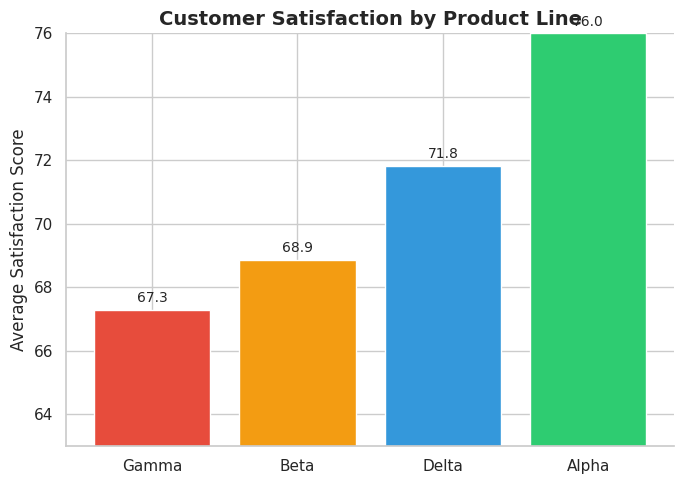

In [4]:
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_sat.index, avg_sat.values, color=["#e74c3c", "#f39c12", "#3498db", "#2ecc71"])
ax.set_ylim(63, 76)
ax.set_ylabel("Average Satisfaction Score")
ax.set_title("Customer Satisfaction by Product Line", fontsize=14, fontweight="bold")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=10)

ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
sns.despine()
plt.tight_layout()
plt.show()

**Your critique of Chart 1:**

*Truncated y-axis: although bars seem so different in their height, they have small differences. Since there used ax.set_ylim(63,76) it's more likely to be zoomed in, but if we zoom out we can definitely see that they are close in size.*

### Misleading Chart 2 — Dual-Axis Trick

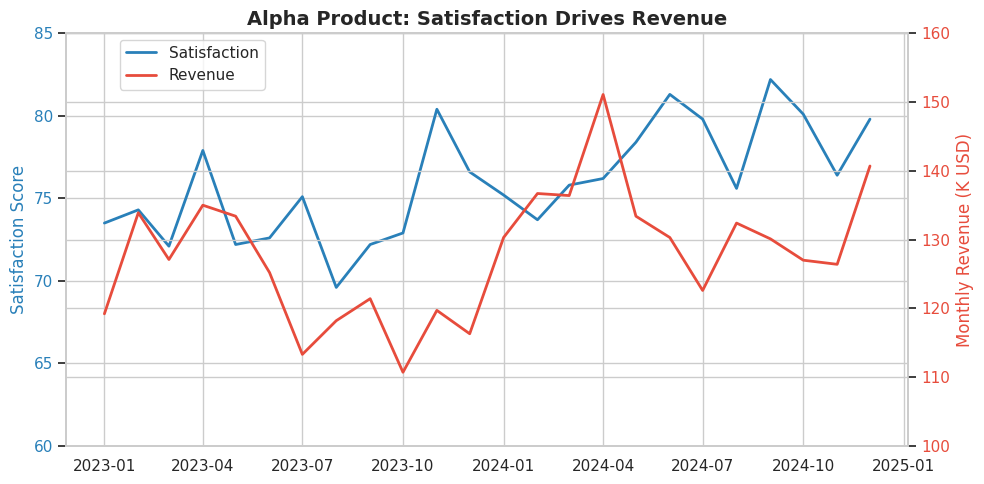

In [ ]:
alpha = df[df["product"] == "Alpha"].set_index("month")

fig, ax1 = plt.subplots(figsize=(10, 5))

color_left = "#2980b9"
ax1.plot(alpha.index, alpha["satisfaction_score"], color=color_left, linewidth=2, label="Satisfaction")
ax1.set_ylabel("Satisfaction Score", color=color_left, fontsize=12)
ax1.set_ylim(60, 85)
ax1.tick_params(axis="y", labelcolor=color_left)

ax2 = ax1.twinx()
color_right = "#e74c3c"
ax2.plot(alpha.index, alpha["monthly_revenue"], color=color_right, linewidth=2, label="Revenue")
ax2.set_ylabel("Monthly Revenue (K USD)", color=color_right, fontsize=12)
ax2.set_ylim(100, 160)
ax2.tick_params(axis="y", labelcolor=color_right)

ax1.set_title("Alpha Product: Satisfaction Drives Revenue", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

**Your critique of Chart 2:**

*Dual axis trick: the graph lines seem so close, because when we set the x-axis the same for each one their y-axis differ in value as it seems in the graph(on left y-axis varies between 60 and 85, on right between 100 and 160). For that reason, we can just set their x-axis the same but y-axis different.*

### Misleading Chart 3 — Cherry-Picked Time Range

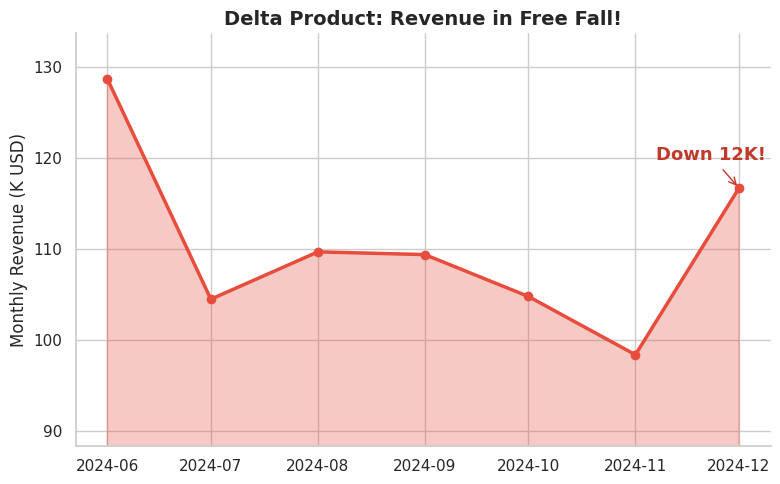

In [ ]:
delta = df[df["product"] == "Delta"].set_index("month")
cherry = delta.loc["2024-06":"2024-12"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(cherry.index, cherry["monthly_revenue"], alpha=0.3, color="#e74c3c")
ax.plot(cherry.index, cherry["monthly_revenue"], color="#e74c3c", linewidth=2.5, marker="o")
ax.set_ylabel("Monthly Revenue (K USD)", fontsize=12)
ax.set_title("Delta Product: Revenue in Free Fall!", fontsize=14, fontweight="bold")
ax.set_ylim(cherry["monthly_revenue"].min() - 10, cherry["monthly_revenue"].max() + 5)

ax.annotate(f"Down {cherry['monthly_revenue'].iloc[0] - cherry['monthly_revenue'].iloc[-1]:.0f}K!",
            xy=(cherry.index[-1], cherry["monthly_revenue"].iloc[-1]),
            fontsize=13, fontweight="bold", color="#c0392b",
            xytext=(-60, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="#c0392b"))

sns.despine()
plt.tight_layout()
plt.show()

**Your critique of Chart 3:**

*The chart focuses only on a 6-month period where revenue declined, ignoring the broader context of the product's performance. It makes the audience believe the product is failing ("Free Fall"), while the data actually shows a cyclical or temporary dip within a larger trend.*

---

## Task 2: Chart Redesign — Fix the Story

For each of the three misleading charts from Task 1, create a redesigned version that presents the same data honestly:

1. Use an appropriate chart type and axis range.
2. Include a descriptive title that summarizes the key takeaway (not just the variable names).
3. Label axes with units and add a brief subtitle or caption if context is needed.
4. Use color intentionally — highlight comparisons, don't just decorate.

**Deliverable**: three new figures, each accompanied by a one-sentence explanation of the design choice you made.

### Redesign 1 — Fixing the Truncated Y-Axis Chart

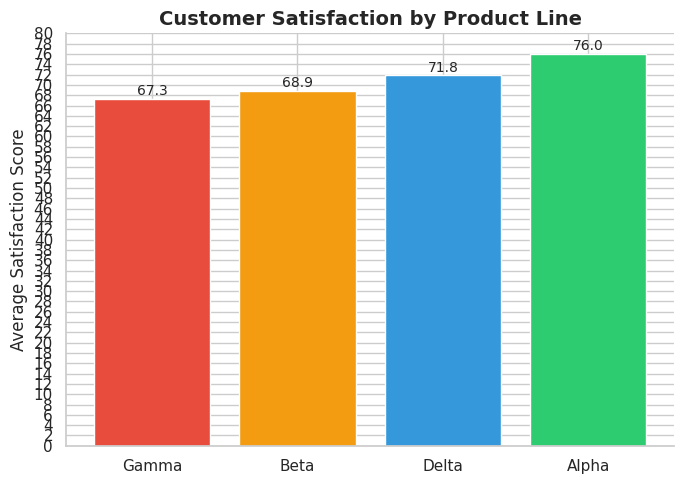

In [26]:
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_sat.index, avg_sat.values, color=["#e74c3c", "#f39c12", "#3498db", "#2ecc71"])
ax.set_ylim(ymin = 0, ymax =80)
ax.set_ylabel("Average Satisfaction Score")
ax.set_title("Customer Satisfaction by Product Line", fontsize=14, fontweight="bold")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=10)

ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
sns.despine()
plt.tight_layout()
plt.show()

**Design choice explanation:**

*As when we zoomed in the difference looked so great, we need to set y limitations again look to the bigger picture*

### Redesign 2 — Fixing the Dual-Axis Chart

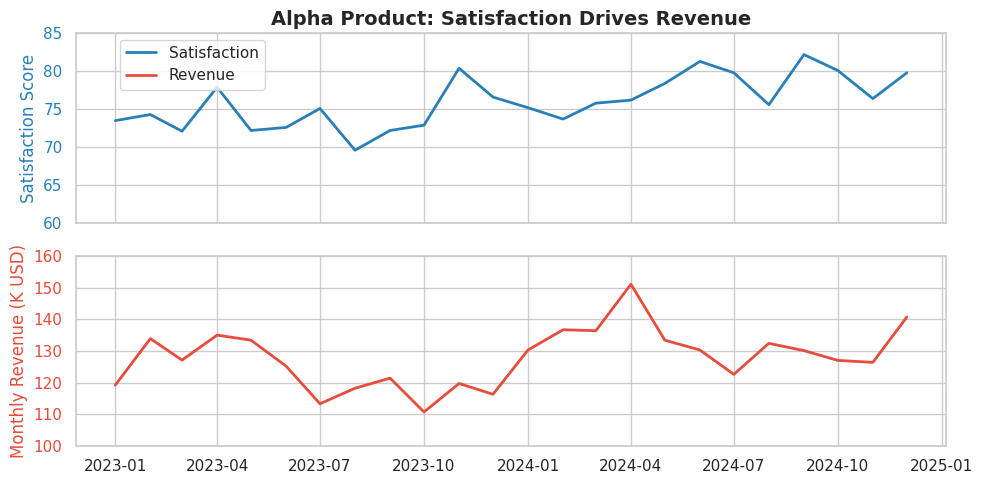

In [27]:
alpha = df[df["product"] == "Alpha"].set_index("month")

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

color_left = "#2980b9"
ax[0].plot(alpha.index, alpha["satisfaction_score"], color=color_left, linewidth=2, label="Satisfaction")
ax[0].set_ylabel("Satisfaction Score", color=color_left, fontsize=12)
ax[0].set_ylim(60, 85)
ax[0].tick_params(axis="y", labelcolor=color_left)
color_right = "#e74c3c"
ax[1].plot(alpha.index, alpha["monthly_revenue"], color=color_right, linewidth=2, label="Revenue")
ax[1].set_ylabel("Monthly Revenue (K USD)", color=color_right, fontsize=12)
ax[1].set_ylim(100, 160)
ax[1].tick_params(axis="y", labelcolor=color_right)

ax[0].set_title("Alpha Product: Satisfaction Drives Revenue", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

**Design choice explanation:**

*When we set ax2=ax1.twinx() we just use the same graph to show both lines with different y values, to prevent this we need to just set sharex(which just demonstrates the same x axis) and then we can show both the lines in 2 rows*

### Redesign 3 — Fixing the Cherry-Picked Time Range Chart

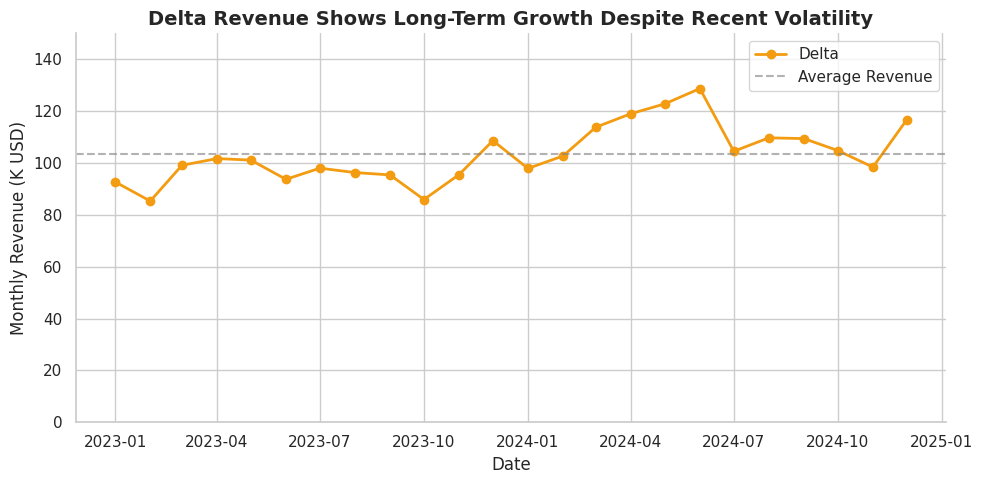

In [28]:
delta_full = df[df["product"] == "Delta"].set_index("month")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(delta_full.index, delta_full["monthly_revenue"], color="#f39c12", linewidth=2, marker='o', label="Delta")

# Adding mean line for context
mean_rev = delta_full["monthly_revenue"].mean()
ax.axhline(mean_rev, color="gray", linestyle="--", alpha=0.6, label="Average Revenue")

ax.set_ylim(0, 150) # Start at 0 for honest scale
ax.set_ylabel("Monthly Revenue (K USD)")
ax.set_xlabel("Date")
ax.set_title("Delta Revenue Shows Long-Term Growth Despite Recent Volatility", fontsize=14, fontweight="bold")
ax.legend()

sns.despine()
plt.tight_layout()
plt.show()

**Design choice explanation:**

*By showing the full two-year timeline and starting the y-axis at zero, it becomes clear that the "free fall" was actually a return to the mean after an unusually high peak, with an overall upward growth trend.*

---

## Task 3: Three-Panel Visual Report

Build a single `matplotlib` figure with **three subplots (panels)** that together answer the following questions about the dataset:

1. **Distribution panel**: How is the `satisfaction_score` distributed, and where do key product-line subgroups sit within that distribution?
2. **Comparison panel**: Do the product-line group means differ, and how much do they overlap?
3. **Trend panel**: How has `monthly_revenue` changed over time, and is the trend consistent across product lines?

**Requirements for each panel:**
- A clear, specific title (not "Plot 1").
- Axis labels with units.
- A legend if multiple groups are shown.
- Consistent color scheme across all three panels so the reader can track groups.

**Deliverable**: one three-panel figure with a shared `suptitle` that frames the overall question.

In [10]:
# Color palette to use consistently across all three panels
palette = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

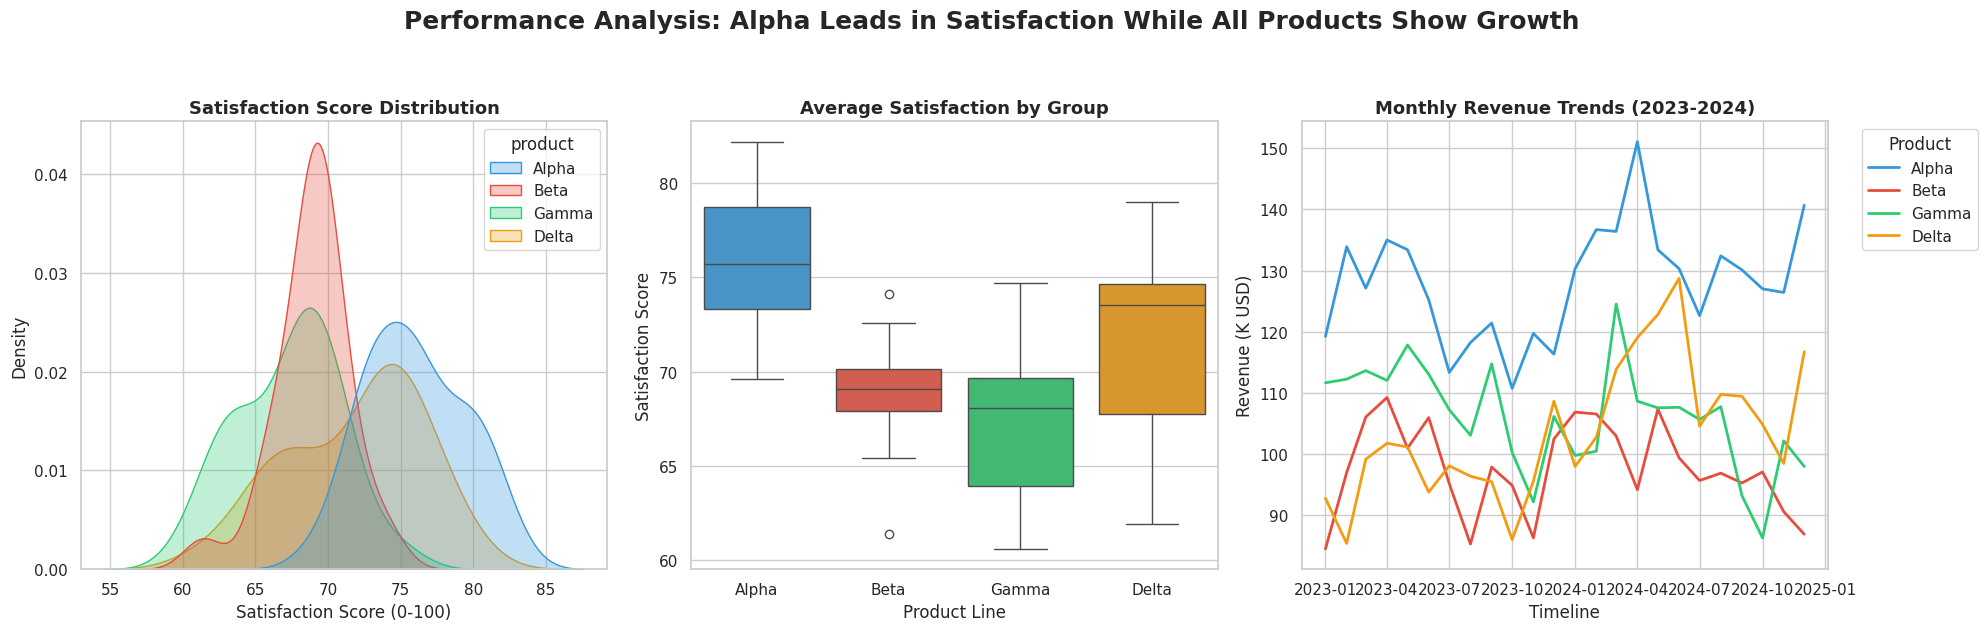

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1 — Distribution
sns.kdeplot(data=df, x="satisfaction_score", hue="product", palette=palette, fill=True, ax=axes[0], alpha=0.3)
axes[0].set_title("Satisfaction Score Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Satisfaction Score (0-100)")
axes[0].set_ylabel("Density")

# Panel 2 — Comparison 
sns.boxplot(data=df, x="product", y="satisfaction_score", palette=palette, ax=axes[1], hue="product", legend=False)
axes[1].set_title("Average Satisfaction by Group", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Product Line")
axes[1].set_ylabel("Satisfaction Score")

# Panel 3 — Trend
sns.lineplot(data=df, x="month", y="monthly_revenue", hue="product", palette=palette, ax=axes[2], linewidth=2)
axes[2].set_title("Monthly Revenue Trends (2023-2024)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Timeline")
axes[2].set_ylabel("Revenue (K USD)")
axes[2].legend(title="Product", bbox_to_anchor=(1.05, 1), loc='upper left')

fig.suptitle("Performance Analysis: Alpha Leads in Satisfaction While All Products Show Growth", 
             fontsize=18, fontweight="bold", y=1.05)

plt.tight_layout()
plt.show()